In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Kelas D_Happiness and Satisfaction.csv', sep=';', decimal=',')

print('Shape:', df.shape)
df.head()

Shape: (111, 11)


,Country,adjusted_satisfaction (0-100),avg_satisfaction (0-10),std_satisfaction,avg_income (&),median_income (&),income_inequality,Region,Happy Score (0-10),GDP,country.1
0,Armenia,37,4.9,2.42,2096.76,1731.506667,31.445556,'Central and Eastern Europe',4.350,0.76821,Armenia
1,Angola,26,4.3,3.19,1448.88,1044.240000,42.720000,'Sub-Saharan Africa',4.033,0.75778,Angola
2,Argentina,60,7.1,1.91,7101.12,5109.400000,45.475556,'Latin America and Caribbean',6.574,1.05351,Argentina
3,Austria,59,7.2,2.11,19457.04,16879.620000,30.296250,'Western Europe',7.200,1.33723,Austria
4,Australia,65,7.6,1.80,19917.00,15846.060000,35.285000,'Australia and New Zealand',7.284,1.33358,Australia


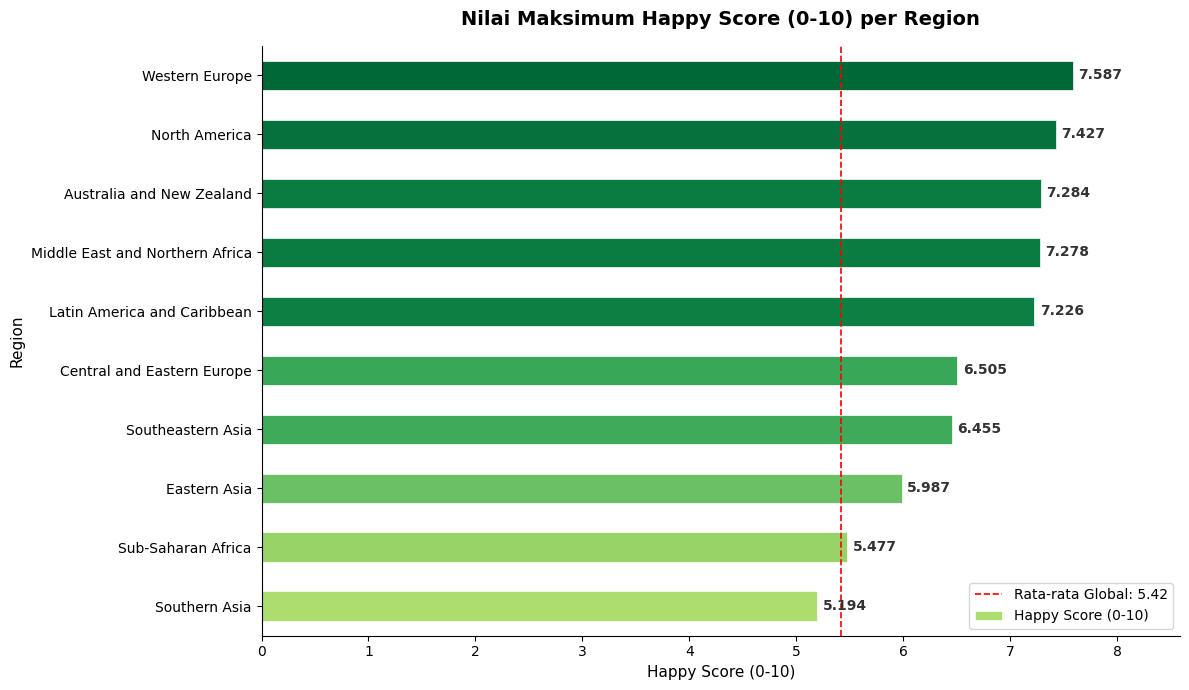

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(12, 7))
ax = axes

# Agregasi: nilai maksimum Happy Score per Region
df_grafik1 = df.groupby('Region')['Happy Score (0-10)'].max().sort_values(ascending=True)

# Warna gradasi berdasarkan nilai
colors = plt.cm.RdYlGn([val / df_grafik1.max() for val in df_grafik1.values])

bars = df_grafik1.plot(kind='barh', ax=ax, color=colors, edgecolor='white', linewidth=0.5)

# Tambahkan label nilai di ujung bar
for i, (value, name) in enumerate(zip(df_grafik1.values, df_grafik1.index)):
    ax.text(value + 0.05, i, f'{value:.3f}', va='center', fontsize=10, fontweight='bold', color='#333333')

# Bersihkan nama region dari tanda kutip
labels = [label.get_text().replace("'", "") for label in ax.get_yticklabels()]
ax.set_yticklabels(labels, fontsize=10)

ax.set_title('Nilai Maksimum Happy Score (0-10) per Region', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Happy Score (0-10)', fontsize=11)
ax.set_ylabel('Region', fontsize=11)
ax.set_xlim(0, df_grafik1.max() + 1)
ax.axvline(x=df['Happy Score (0-10)'].mean(), color='red', linestyle='--', linewidth=1.2, label=f'Rata-rata Global: {df["Happy Score (0-10)"].mean():.2f}')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('grafik1.png', dpi=150, bbox_inches='tight')
plt.show()


Shape Dataset : (111, 11)


,Country,adjusted_satisfaction (0-100),avg_satisfaction (0-10),std_satisfaction,avg_income (&),median_income (&),income_inequality,Region,Happy Score (0-10),GDP,country.1
0,Armenia,37,4.9,2.42,2096.76,1731.506667,31.445556,'Central and Eastern Europe',4.350,0.76821,Armenia
1,Angola,26,4.3,3.19,1448.88,1044.240000,42.720000,'Sub-Saharan Africa',4.033,0.75778,Angola
2,Argentina,60,7.1,1.91,7101.12,5109.400000,45.475556,'Latin America and Caribbean',6.574,1.05351,Argentina
3,Austria,59,7.2,2.11,19457.04,16879.620000,30.296250,'Western Europe',7.200,1.33723,Austria
4,Australia,65,7.6,1.80,19917.00,15846.060000,35.285000,'Australia and New Zealand',7.284,1.33358,Australia



Rata-rata Global Happy Score : 5.42

Jumlah negara yang memenuhi filter : 0


,Country,Region,avg_income (&),Happy Score (0-10)


,Country,avg_income (&),Happy Score (0-10)
49,Italy,15437.59500,5.948
34,France,18096.78857,6.575
25,Germany,19285.96000,6.750
36,United Kingdom,17099.55000,6.867
7,Belgium,17168.50500,6.937
44,Ireland,16657.77000,6.940
61,Luxembourg,26182.27500,6.946
105,United States,23127.00000,7.119
3,Austria,19457.04000,7.200
4,Australia,19917.00000,7.284


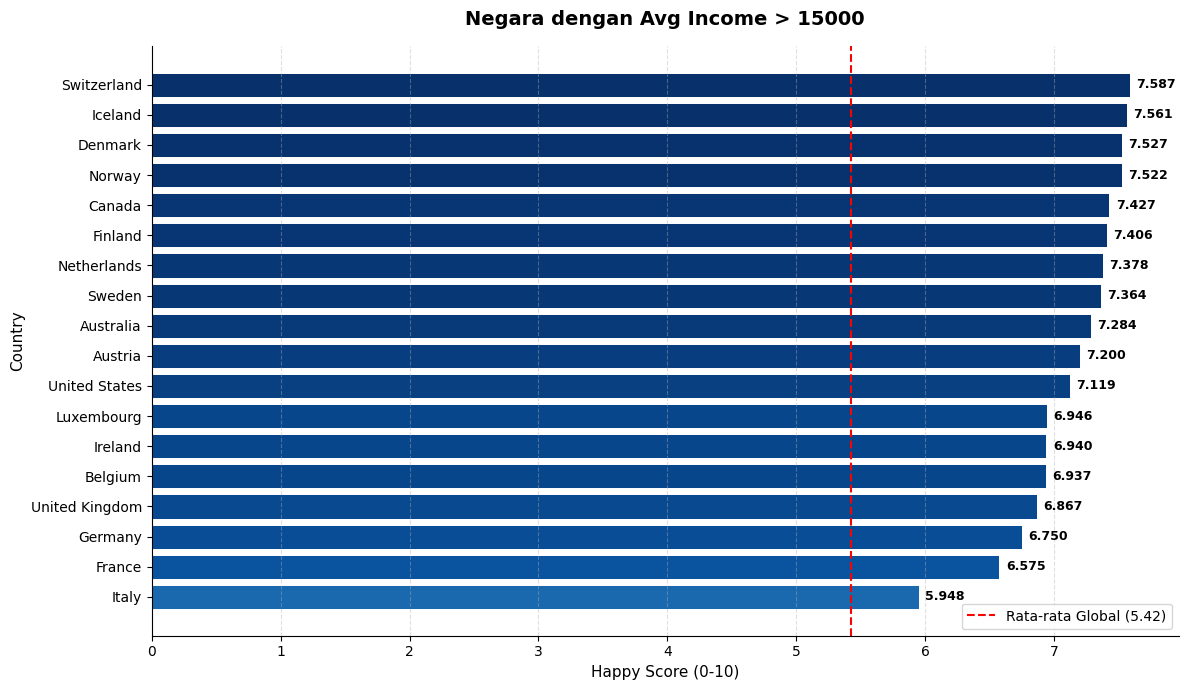


Kesimpulan:
Tidak terdapat negara dengan avg_income > 15000 yang memiliki Happy Score di bawah rata-rata global.
Happy Score terendah pada kelompok ini adalah Italy (5.948), masih di atas rata-rata global.


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# baca dataset
df = pd.read_csv(
    'Kelas D_Happiness and Satisfaction.csv',
    sep=';',
    decimal=','
)

print('Shape Dataset :', df.shape)
display(df.head())

rata_global = df['Happy Score (0-10)'].mean()
print('\nRata-rata Global Happy Score :', round(rata_global, 2))

# filter negara income > 15000 dan happy score < rata-rata global
df_filter = df[
    (df['avg_income (&)'] > 15000) &
    (df['Happy Score (0-10)'] < rata_global)
]

print('\nJumlah negara yang memenuhi filter :', len(df_filter))
display(df_filter[['Country', 'Region', 'avg_income (&)', 'Happy Score (0-10)']])

# semua negara dengan income tinggi
df_income_tinggi = df[df['avg_income (&)'] > 15000].copy()
df_income_tinggi = df_income_tinggi.sort_values(by='Happy Score (0-10)', ascending=True)
display(df_income_tinggi[['Country', 'avg_income (&)', 'Happy Score (0-10)']])

# membuat grafik
fig, axes = plt.subplots(1, 1, figsize=(12, 7))
ax = axes

colors = plt.cm.Blues(
    [val / df_income_tinggi['Happy Score (0-10)'].max()
     for val in df_income_tinggi['Happy Score (0-10)']]
)

bars = ax.barh(
    df_income_tinggi['Country'],
    df_income_tinggi['Happy Score (0-10)'],
    color=colors,
    edgecolor='white',
    linewidth=0.7
)

for i, value in enumerate(df_income_tinggi['Happy Score (0-10)']):
    ax.text(value + 0.05, i, f'{value:.3f}', va='center', fontsize=9, fontweight='bold')

# garis rata-rata global
ax.axvline(
    x=rata_global,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label=f'Rata-rata Global ({rata_global:.2f})'
)

ax.set_title('Negara dengan Avg Income > 15000', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Happy Score (0-10)', fontsize=11)
ax.set_ylabel('Country', fontsize=11)
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('grafik2_tiana.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nKesimpulan:')
print('Tidak terdapat negara dengan avg_income > 15000 yang memiliki Happy Score di bawah rata-rata global.')
print('Happy Score terendah pada kelompok ini adalah Italy (5.948), masih di atas rata-rata global.')

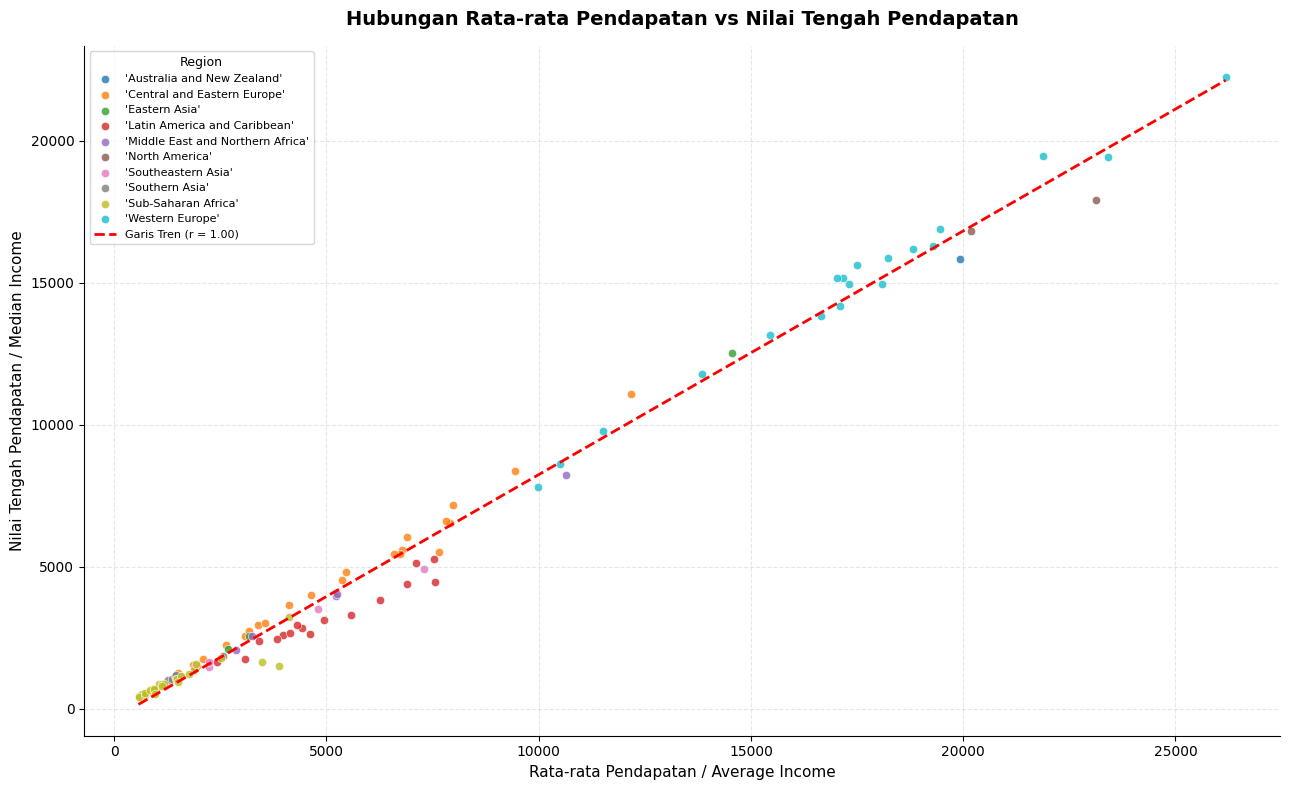

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Mengambil kolom yang dianalisis dan menghapus data kosong
df_grafik3 = df[['Region', 'avg_income (&)', 'median_income (&)']].dropna()

# Menentukan data sumbu X dan Y
x = df_grafik3['avg_income (&)']
y = df_grafik3['median_income (&)']

# Menghitung nilai korelasi
korelasi = x.corr(y)

# Menghitung garis tren
koefisien = np.polyfit(x, y, 1)
x_garis = np.linspace(x.min(), x.max(), 100)
y_garis = koefisien[0] * x_garis + koefisien[1]

# Membuat scatter plot dengan pendekatan objek
fig, axes = plt.subplots(1, 1, figsize=(13, 8), squeeze=False)
ax = axes[0, 0]

# Membuat titik-titik observasi berdasarkan Region
for region, data_region in df_grafik3.groupby('Region'):
    ax.scatter(
        data_region['avg_income (&)'],
        data_region['median_income (&)'],
        alpha=0.8,
        edgecolors='white',
        linewidth=0.5,
        label=region
    )

# Menambahkan garis tren
ax.plot(
    x_garis,
    y_garis,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Garis Tren (r = {korelasi:.2f})'
)

# Judul dan label sumbu
ax.set_title(
    'Hubungan Rata-rata Pendapatan vs Nilai Tengah Pendapatan',
    fontsize=14,
    fontweight='bold',
    pad=15
)
ax.set_xlabel('Rata-rata Pendapatan / Average Income', fontsize=11)
ax.set_ylabel('Nilai Tengah Pendapatan / Median Income', fontsize=11)

# Merapikan tampilan grafik
ax.legend(
    title='Region',
    fontsize=8,
    title_fontsize=9,
    loc='upper left'
)
ax.grid(True, linestyle='--', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('grafik3.png', dpi=150, bbox_inches='tight')
plt.show()

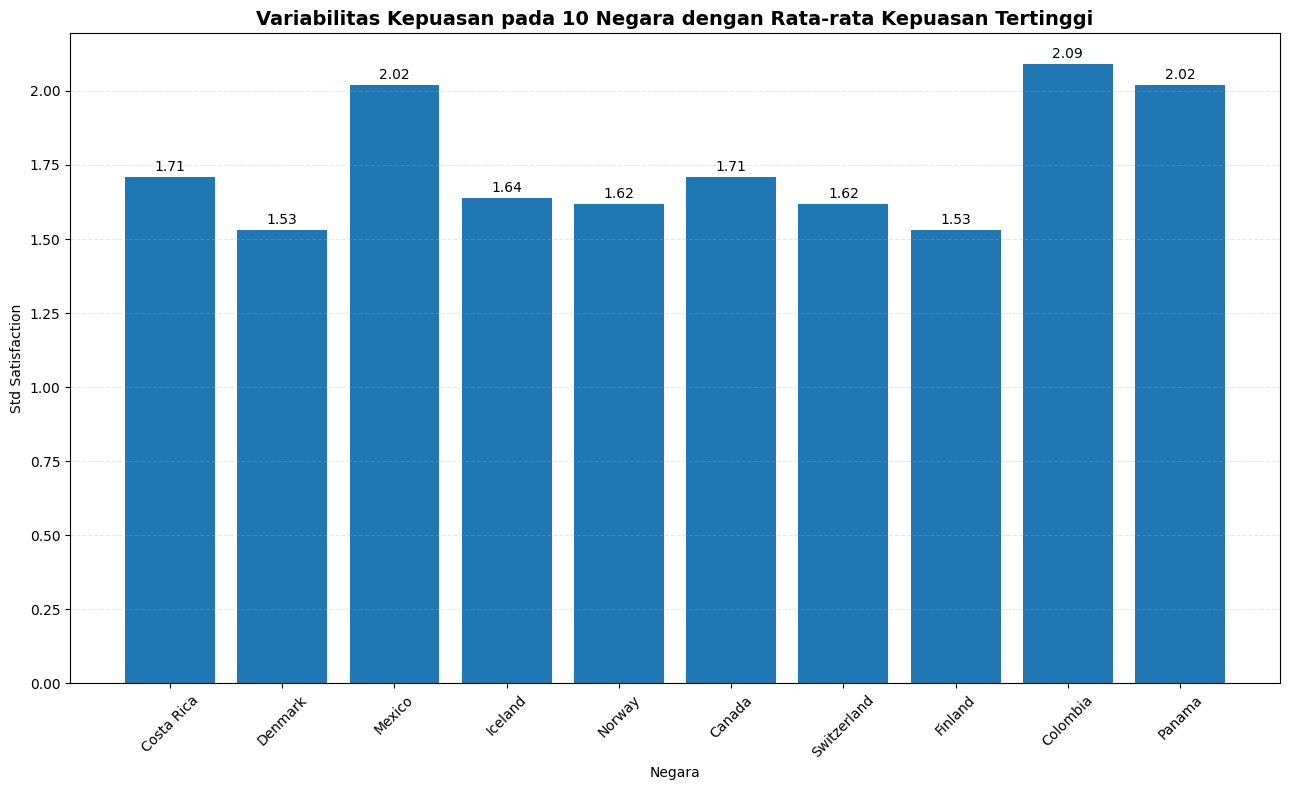

In [ ]:
import matplotlib.pyplot as plt

# Mengambil 10 negara dengan rata-rata kepuasan tertinggi
df_grafik4 = (
    df[['Country',
        'avg_satisfaction (0-10)',
        'std_satisfaction']]
    .dropna()
    .sort_values(by='avg_satisfaction (0-10)', ascending=False)
    .head(10)
)

# Membuat figure dengan pendekatan objek
fig, axes = plt.subplots(1, 1, figsize=(13, 8), squeeze=False)
ax = axes[0, 0]

# Membuat bar chart
bars = ax.bar(
    df_grafik4['Country'],
    df_grafik4['std_satisfaction']
)

# Menampilkan nilai di atas batang
for bar in bars:
    tinggi = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        tinggi + 0.02,
        f'{tinggi:.2f}',
        ha='center'
    )

# Judul dan label
ax.set_title(
    'Variabilitas Kepuasan pada 10 Negara dengan Rata-rata Kepuasan Tertinggi',
    fontsize=14,
    fontweight='bold'
)

ax.set_xlabel('Negara')
ax.set_ylabel('Std Satisfaction')

ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

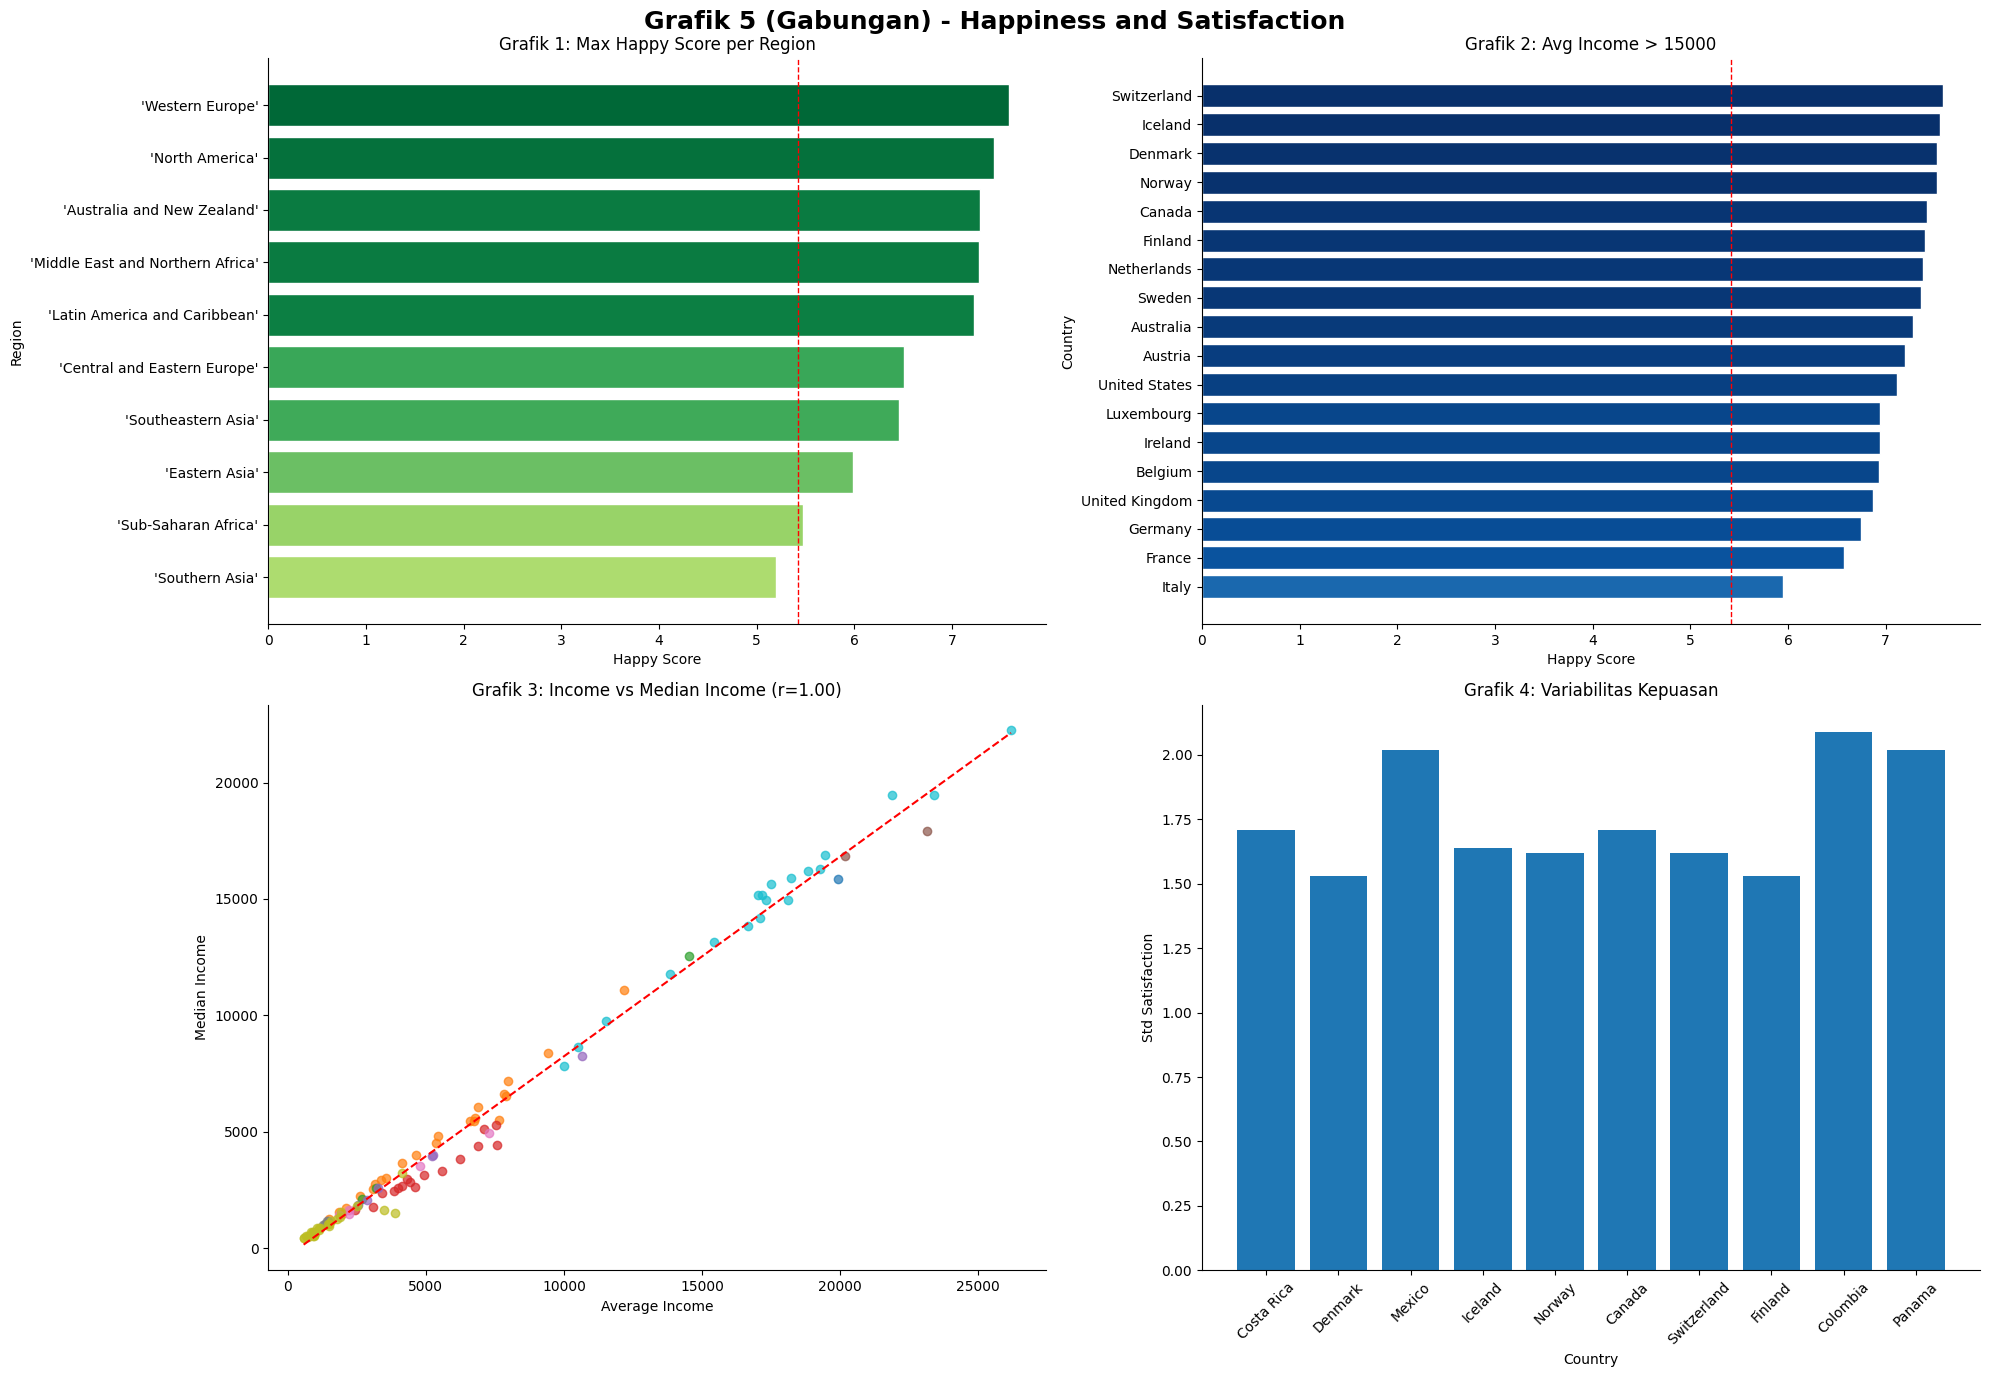

In [5]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(20, 14))

#grafik 1
ax = axes[0, 0]

g1 = df.groupby('Region')['Happy Score (0-10)'].max().sort_values(ascending=True)
colors = plt.cm.RdYlGn([v / g1.max() for v in g1.values])

ax.barh(g1.index, g1.values, color=colors, edgecolor='white')
ax.axvline(df['Happy Score (0-10)'].mean(), color='red', linestyle='--', linewidth=1)
ax.set_title('Grafik 1: Max Happy Score per Region')
ax.set_xlabel('Happy Score')
ax.set_ylabel('Region')

#grafik 2
ax = axes[0, 1]

rata_global = df['Happy Score (0-10)'].mean()
g2 = df[df['avg_income (&)'] > 15000].sort_values('Happy Score (0-10)', ascending=True)
colors2 = plt.cm.Blues(g2['Happy Score (0-10)'] / g2['Happy Score (0-10)'].max())

ax.barh(g2['Country'], g2['Happy Score (0-10)'], color=colors2, edgecolor='white')
ax.axvline(rata_global, color='red', linestyle='--', linewidth=1)
ax.set_title('Grafik 2: Avg Income > 15000')
ax.set_xlabel('Happy Score')
ax.set_ylabel('Country')

#grafik 3
ax = axes[1, 0]

g3 = df[['Region', 'avg_income (&)', 'median_income (&)']].dropna()
x = g3['avg_income (&)']
y = g3['median_income (&)']

korelasi = x.corr(y)
koef = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 100)

for region, d in g3.groupby('Region'):
    ax.scatter(d['avg_income (&)'], d['median_income (&)'], alpha=0.7, label=region)

ax.plot(x_line, koef[0]*x_line + koef[1], color='red', linestyle='--')
ax.set_title(f'Grafik 3: Income vs Median Income (r={korelasi:.2f})')
ax.set_xlabel('Average Income')
ax.set_ylabel('Median Income')

#grafik 4
ax = axes[1, 1]

g4 = (df[['Country', 'avg_satisfaction (0-10)', 'std_satisfaction']]
        .dropna()
        .sort_values('avg_satisfaction (0-10)', ascending=False)
        .head(10))

ax.bar(g4['Country'], g4['std_satisfaction'])
ax.set_title('Grafik 4: Variabilitas Kepuasan')
ax.set_xlabel('Country')
ax.set_ylabel('Std Satisfaction')
ax.tick_params(axis='x', rotation=45)

for ax in axes.flat:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Grafik 5 (Gabungan) - Happiness and Satisfaction', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.savefig('grafik5_gabungan.png', dpi=150, bbox_inches='tight')
plt.show()